In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [2]:
df = pd.read_csv("../data/fitness_data.csv")

df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)

# Ensure speed exists
df["Speed_kmph"] = df["Distance_km"] / (df["Time_min"] / 60)

df.head()

,Distance_km,Time_min,Calories,Weight_kg,Speed_kmph
Date,,,,,
2026-01-01,2.10,13.55,133.87,70.19,9.298893
2026-01-02,2.02,13.07,112.30,69.69,9.273145
2026-01-03,2.23,14.16,147.90,69.58,9.449153
2026-01-04,2.46,15.52,133.41,69.99,9.510309
2026-01-05,2.16,14.00,135.26,69.73,9.257143


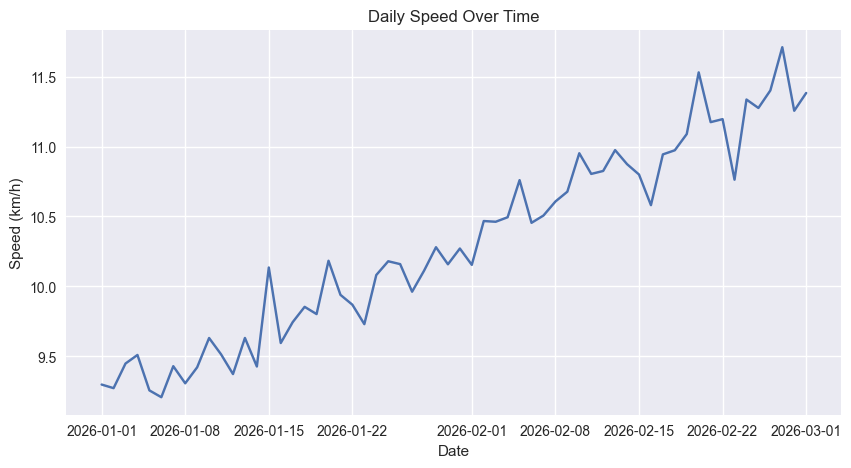

In [3]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df["Speed_kmph"])
plt.title("Daily Speed Over Time")
plt.xlabel("Date")
plt.ylabel("Speed (km/h)")
plt.show()

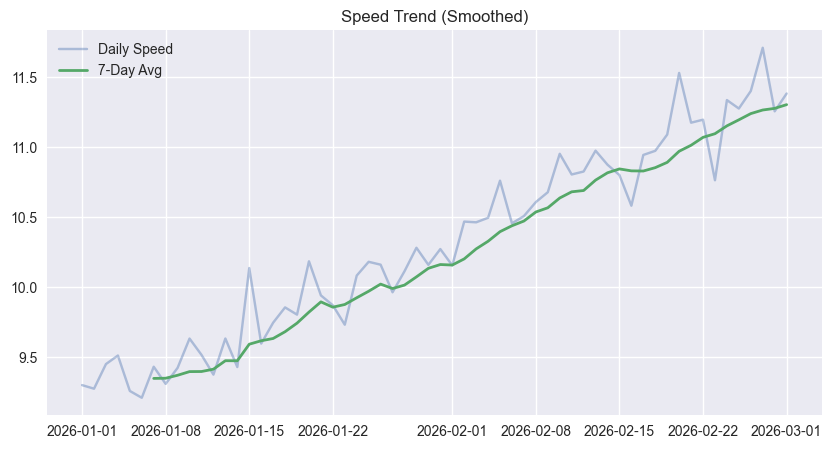

In [4]:
df["Rolling_7D_Speed"] = df["Speed_kmph"].rolling(7).mean()

plt.figure(figsize=(10,5))
plt.plot(df.index, df["Speed_kmph"], alpha=0.4, label="Daily Speed")
plt.plot(df.index, df["Rolling_7D_Speed"], linewidth=2, label="7-Day Avg")
plt.title("Speed Trend (Smoothed)")
plt.legend()
plt.show()

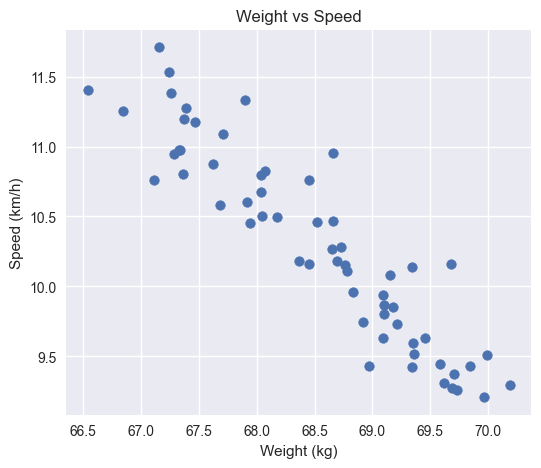

Correlation: -0.923385289032982


In [5]:
plt.figure(figsize=(6,5))
plt.scatter(df["Weight_kg"], df["Speed_kmph"])
plt.title("Weight vs Speed")
plt.xlabel("Weight (kg)")
plt.ylabel("Speed (km/h)")
plt.show()

correlation = np.corrcoef(df["Weight_kg"], df["Speed_kmph"])[0,1]
print("Correlation:", correlation)

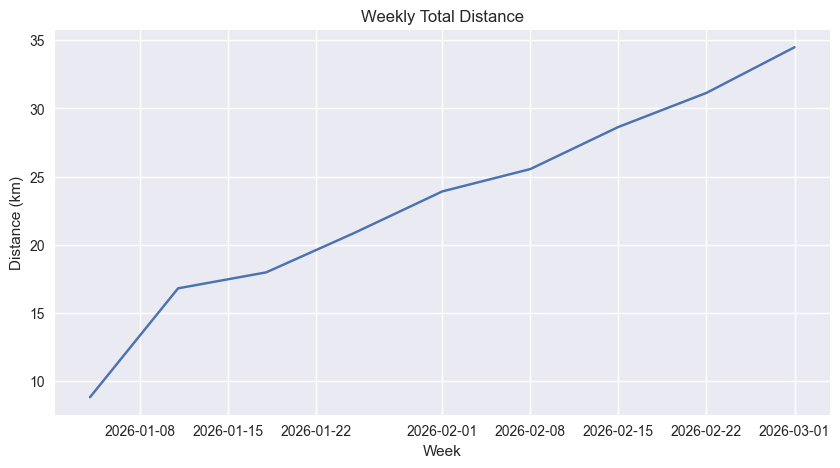

In [6]:
weekly_distance = df["Distance_km"].resample("W").sum()

plt.figure(figsize=(10,5))
plt.plot(weekly_distance.index, weekly_distance)
plt.title("Weekly Total Distance")
plt.xlabel("Week")
plt.ylabel("Distance (km)")
plt.show()

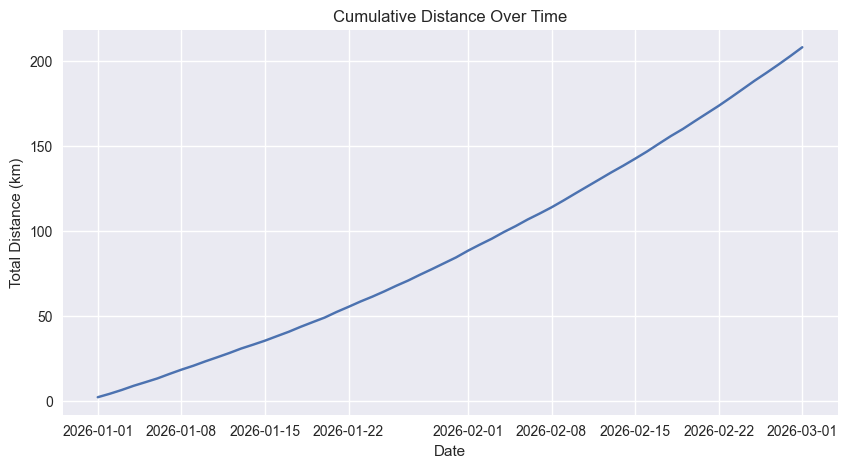

In [7]:
df["Cumulative_Distance"] = df["Distance_km"].cumsum()

plt.figure(figsize=(10,5))
plt.plot(df.index, df["Cumulative_Distance"])
plt.title("Cumulative Distance Over Time")
plt.xlabel("Date")
plt.ylabel("Total Distance (km)")
plt.show()

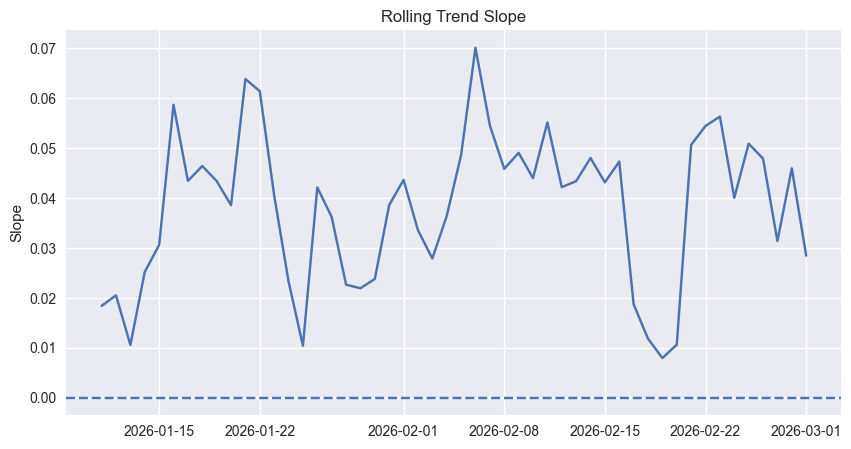

In [8]:
window = 10
slopes = []

for i in range(len(df)):
    if i < window:
        slopes.append(np.nan)
    else:
        y = df["Speed_kmph"].iloc[i-window:i]
        x = np.arange(window)
        slope = np.polyfit(x, y, 1)[0]
        slopes.append(slope)

df["Rolling_Slope"] = slopes

plt.figure(figsize=(10,5))
plt.plot(df.index, df["Rolling_Slope"])
plt.axhline(0, linestyle="--")
plt.title("Rolling Trend Slope")
plt.ylabel("Slope")
plt.show()